In [19]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Pulse Radar SAR Imaging: Strip-Map SAR via Back-Projection

**SAR** synthesises a large virtual aperture by coherently combining pulse returns as the platform moves, achieving fine azimuth resolution independent of range.

| Quantity | Formula | This example |
|---|---|---|
| Range resolution | $\Delta R = c/(2B)$ | 5 m (B = 30 MHz) |
| SAR azimuth res. | $\Delta_{az} = D_a/2$ | 0.5 m ($D_a$ = 1 m) |
| Back-Projection | $I(x_p,y_p)=\sum_n s_n\!\left(2R_n/c\right)e^{j4\pi R_n/\lambda}$ | 60 pulses |

**Scene**: 3 point targets, X-band (10 GHz), 1 km standoff, platform speed 100 m/s.

## Setup

In [20]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import Image, display
from scipy import constants
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

In [21]:
c = constants.c  # Speed of light (m/s)

# Carrier / waveform
fc = 10e9          # Carrier frequency (Hz)
lam = c / fc       # Wavelength (m)
B = 30e6           # Pulse bandwidth (Hz)  →  ΔR = c/(2B) ≈ 5 m
pulse_width = 1 / B  # Rectangular pulse width (s)
prf = 500          # Pulse repetition frequency (Hz)
prp = 1 / prf      # Pulse repetition period (s)
fs = 2 * B         # ADC sample rate (Hz)
tx_power_dbm = 40  # Transmit power (dBm)
num_pulses = 60    # Number of pulses

# Platform / geometry
v_platform = 100.0   # Along-track velocity (m/s)
r0 = 1000.0          # Broadside standoff range (m)

# Derived quantities
range_res = c / (2 * B)
az_res_sar = 0.5  # = D_a/2  (D_a = 1 m antenna)
max_range = c / (2 * prf)
samples_per_pulse = int(prp * fs)
aperture_time = num_pulses / prf
synthetic_aperture = v_platform * aperture_time

print(f"fc={fc/1e9:.0f} GHz  B={B/1e6:.0f} MHz  PRF={prf} Hz  N={num_pulses} pulses")
print(f"ΔR={range_res:.1f} m  Δaz={az_res_sar:.2f} m  aperture={synthetic_aperture:.1f} m")

fc=10 GHz  B=30 MHz  PRF=500 Hz  N=60 pulses
ΔR=5.0 m  Δaz=0.50 m  aperture=12.0 m


### Transmitter, Receiver & Radar Object

A rectangular pulse is defined via `amp`/`mod_t` arrays. The antenna uses a cos²⁰ azimuth taper (≈ 12° beamwidth). The receiver is co-located (monostatic SAR, $f_s = 2B$).

In [22]:
# ── Antenna pattern ────────────────────────────────────────────────────────────
antenna_gain = 20  # dBi — moderate gain directional antenna

# Azimuth: cos^20 taper  → ~12° beamwidth @ −3 dB (strip-map illumination)
az_angle = np.arange(-60, 61, 1)
az_pattern = 20 * np.log10(np.abs(np.cos(az_angle / 180 * np.pi)) ** 20) + antenna_gain

# Elevation: cos^60 taper → ~8° beamwidth @ −3 dB
el_angle = np.arange(-30, 31, 1)
el_pattern = 20 * np.log10(np.abs(np.cos(el_angle / 180 * np.pi)) ** 60) + antenna_gain

# ── Pulse envelope (rectangular) ─────────────────────────────────────────────
total_samples = int(prp * num_pulses * fs)
mod_t = np.arange(0, total_samples) / fs
amp = np.zeros(total_samples)
amp[mod_t <= pulse_width] = 1.0  # rectangular pulse ON for first pulse_width seconds

# ── TX channel ────────────────────────────────────────────────────────────────
tx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
    amp=amp,
    mod_t=mod_t,
)

tx = Transmitter(
    f=fc,
    t=prp,
    tx_power=tx_power_dbm,
    pulses=num_pulses,
    channels=[tx_channel],
)

print("Transmitter configured.")
print(f"  Pulse envelope samples : {int(np.sum(amp > 0))} / {total_samples}")
print(f"  Duty cycle             : {np.sum(amp > 0) / total_samples * 100:.3f}%")

Transmitter configured.
  Pulse envelope samples : 3 / 7200000
  Duty cycle             : 0.000%


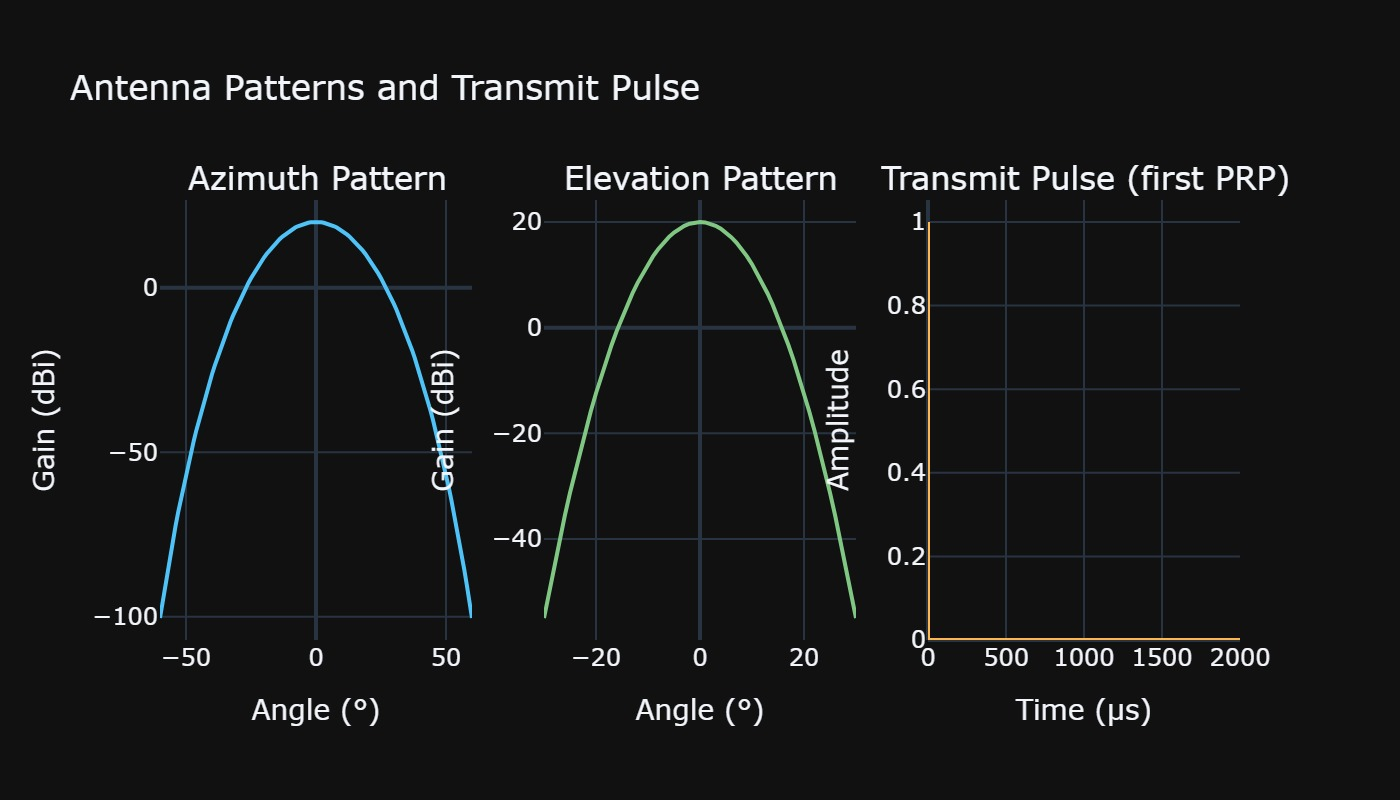

In [23]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Azimuth Pattern", "Elevation Pattern", "Transmit Pulse (first PRP)"),
)

fig.add_trace(
    go.Scatter(x=az_angle, y=az_pattern, name="Azimuth",
               line=dict(color="#4FC3F7", width=2)),
    row=1, col=1,
)
fig.add_trace(
    go.Scatter(x=el_angle, y=el_pattern, name="Elevation",
               line=dict(color="#81C784", width=2)),
    row=1, col=2,
)

t_us = mod_t[:samples_per_pulse] * 1e6  # µs
fig.add_trace(
    go.Scatter(
        x=t_us, y=amp[:samples_per_pulse],
        name="Amplitude", line=dict(color="#FFB74D", width=2), fill="tozeroy",
    ),
    row=1, col=3,
)

fig.update_xaxes(title_text="Angle (°)", row=1, col=1)
fig.update_xaxes(title_text="Angle (°)", row=1, col=2)
fig.update_xaxes(title_text="Time (µs)", row=1, col=3)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=1)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=2)
fig.update_yaxes(title_text="Amplitude", row=1, col=3)

fig.update_layout(
    title="Antenna Patterns and Transmit Pulse",
    template="plotly_dark", height=400, showlegend=False,
)
show(fig)

In [24]:
rx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

rx = Receiver(
    fs=fs,
    noise_figure=5,    # NF = 5 dB
    rf_gain=20,        # LNA gain = 20 dB
    baseband_gain=30,  # Baseband gain = 30 dB
    channels=[rx_channel],
)

print("Receiver configured.")
print(f"  Sample rate    : {fs/1e6:.0f} MHz")
print(f"  Samples/pulse  : {samples_per_pulse}")

Receiver configured.
  Sample rate    : 60 MHz
  Samples/pulse  : 120000


### Platform Trajectory & Scene

The platform flies along +x at constant speed. Three point scatterers test range and azimuth resolution:

| Target | x (m) | y (m) | RCS (dBsm) |
|--------|-------|-------|------------|
| A | 0 | 1000 | 10 |
| B | +20 | 1000 | 5 |
| C | +5 | 1020 | 0 |

In [25]:
# Platform flies along +x; aperture centred at x = 0
pulse_times = np.arange(num_pulses) * prp
pulse_times -= pulse_times.mean()
platform_x = v_platform * pulse_times  # along-track positions (m)

In [26]:
# location: (num_pulses, 3) — one [x, y, z] position per frame
# locations = np.column_stack([
#     platform_x,
#     np.zeros(num_pulses),   # no cross-track offset
#     np.zeros(num_pulses),   # altitude 0 (2-D geometry)
# ])

radar = Radar(
    transmitter=tx,
    receiver=rx,
    # rotation=[90, 0, 0],
    # location=locations,      # (num_pulses, 3)
    # frame_time=pulse_times,  # (num_pulses,) in seconds
)

locations = [radar.time_prop["timestamp"]*v_platform,0,0]

radar.set_motion(location=locations, rotation=[90, 0, 0])

print(f"Radar created with {num_pulses} frames (pulses).")

Radar created with 60 frames (pulses).


In [27]:
targets = [
    {"location": (0.0,  r0,      0.0), "rcs": 10.0, "phase": 0.0},  # A: centre
    {"location": (20.0, r0,      0.0), "rcs":  5.0, "phase": 0.0},  # B: +20 m az
    {"location": (5.0,  r0 + 20, 0.0), "rcs":  0.0, "phase": 0.0},  # C: +20 m range
]

print("Targets:")
for i, t in enumerate(targets):
    x, y, z = t["location"]
    slant = np.hypot(y, x)
    print(f"  Target {chr(65+i)}: x={x:+.1f} m, y={y:.0f} m  "
          f"(slant R ≈ {slant:.1f} m)  RCS = {t['rcs']} dBsm")

Targets:
  Target A: x=+0.0 m, y=1000 m  (slant R ≈ 1000.0 m)  RCS = 10.0 dBsm
  Target B: x=+20.0 m, y=1000 m  (slant R ≈ 1000.2 m)  RCS = 5.0 dBsm
  Target C: x=+5.0 m, y=1020 m  (slant R ≈ 1020.0 m)  RCS = 0.0 dBsm


## Simulation & SAR Processing

Run `sim_radar` to obtain the complex baseband signal `baseband[rx, pulse, sample]`, then apply:
1. **Matched filtering** (range compression)
2. **Back-Projection** (azimuth focusing)

In [28]:
data = sim_radar(radar, targets, density=1)

baseband = data["baseband"]    # complex I/Q: (rx_ch, pulses, fast-time samples)
timestamp = data["timestamp"]  # time stamps:  (rx_ch, pulses, fast-time samples)

print("Simulation complete.")
print(f"  baseband shape : {baseband.shape}")
print(f"    dim 0 : {baseband.shape[0]} RX channel(s)")
print(f"    dim 1 : {baseband.shape[1]} pulses (synthetic aperture)")
print(f"    dim 2 : {baseband.shape[2]} fast-time samples per pulse")

Simulation complete.
  baseband shape : (1, 60, 120000)
    dim 0 : 1 RX channel(s)
    dim 1 : 60 pulses (synthetic aperture)
    dim 2 : 120000 fast-time samples per pulse


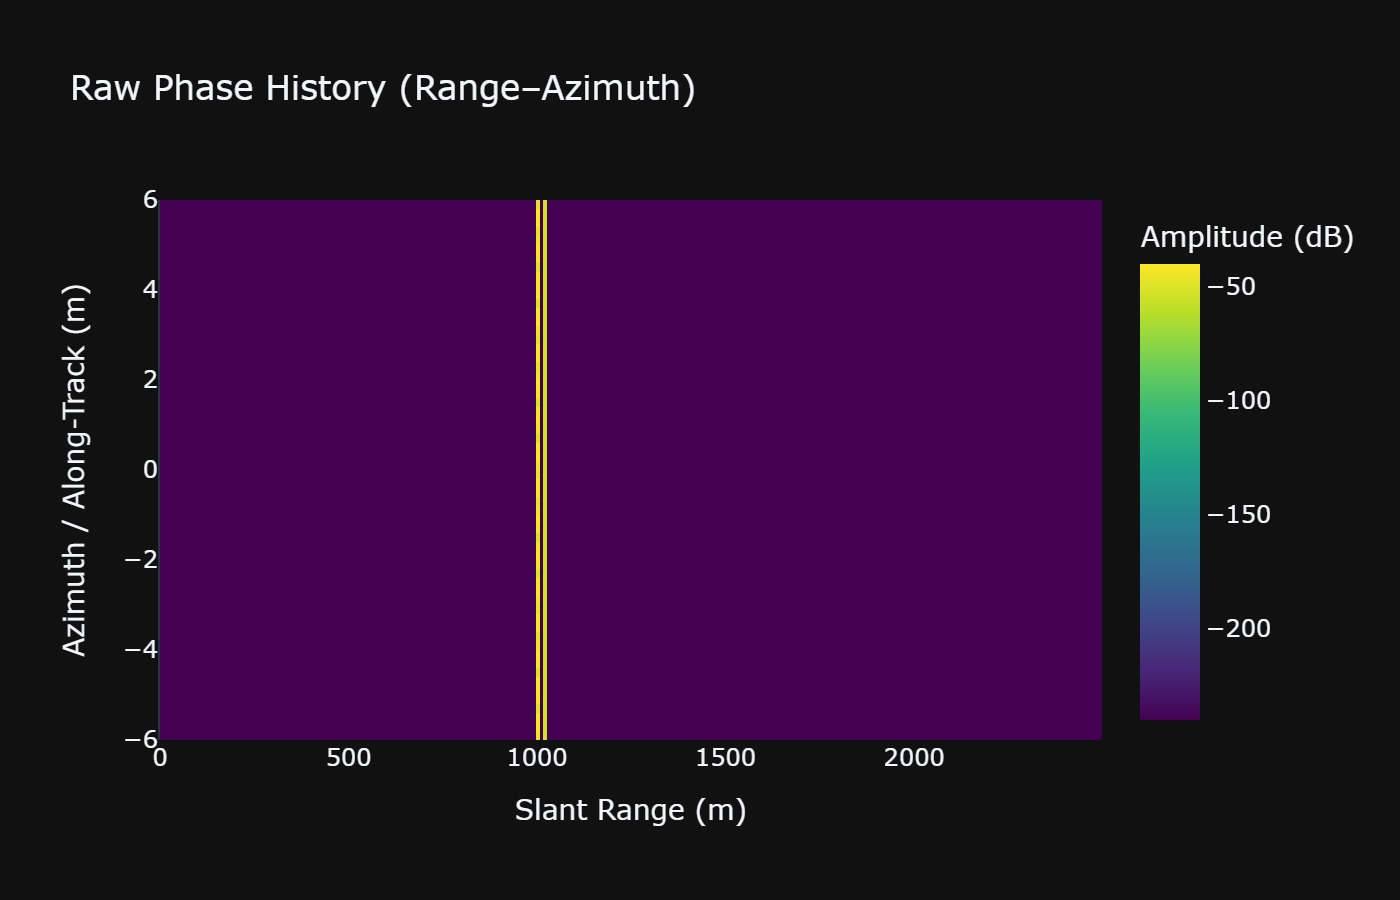

In [29]:
raw = baseband[0,:,:]  # single RX channel: (num_pulses, samples_per_pulse)

# Fast-time → slant range axis
fast_time = np.arange(samples_per_pulse) / fs
slant_range = fast_time * c / 2

az_positions = platform_x  # along-track positions of each pulse

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=slant_range, y=az_positions,
        z=20 * np.log10(np.abs(baseband[0,:,0:1000]) + 1e-12),
        colorscale="Viridis",
        colorbar=dict(title="Amplitude (dB)"),
        # zmin=-60, zmax=0,
    )
)
fig.update_layout(
    title="Raw Phase History (Range–Azimuth)",
    xaxis_title="Slant Range (m)",
    yaxis_title="Azimuth / Along-Track (m)",
    template="plotly_dark", height=450,
)
show(fig)

### Step 1: Range Compression (Matched Filter)

In [30]:
# ── Matched filter (replica correlation) ─────────────────────────────────────
pulse_samples = int(np.ceil(pulse_width * fs))
replica = np.zeros(samples_per_pulse, dtype=complex)
replica[:pulse_samples] = 1.0   # rectangular pulse replica

# Convolve each pulse with the conjugate-time-reversed replica via FFT
NFFT = samples_per_pulse
REPLICA_FFT = np.fft.fft(np.conj(replica[::-1]), NFFT)

raw_mf = np.zeros_like(raw)
for i in range(num_pulses):
    raw_mf[i] = np.fft.ifft(np.fft.fft(raw[i], NFFT) * REPLICA_FFT)

print(f"Range matched filtering complete.  Shape: {raw_mf.shape}")
print(f"  Range resolution after MF : {range_res:.2f} m  (c / 2B)")

Range matched filtering complete.  Shape: (60, 120000)
  Range resolution after MF : 5.00 m  (c / 2B)


### Step 2: Range-Compressed Phase History

After MF the pulse width contracts to ΔR = c/(2B); hyperbolic target tracks become clearly visible.

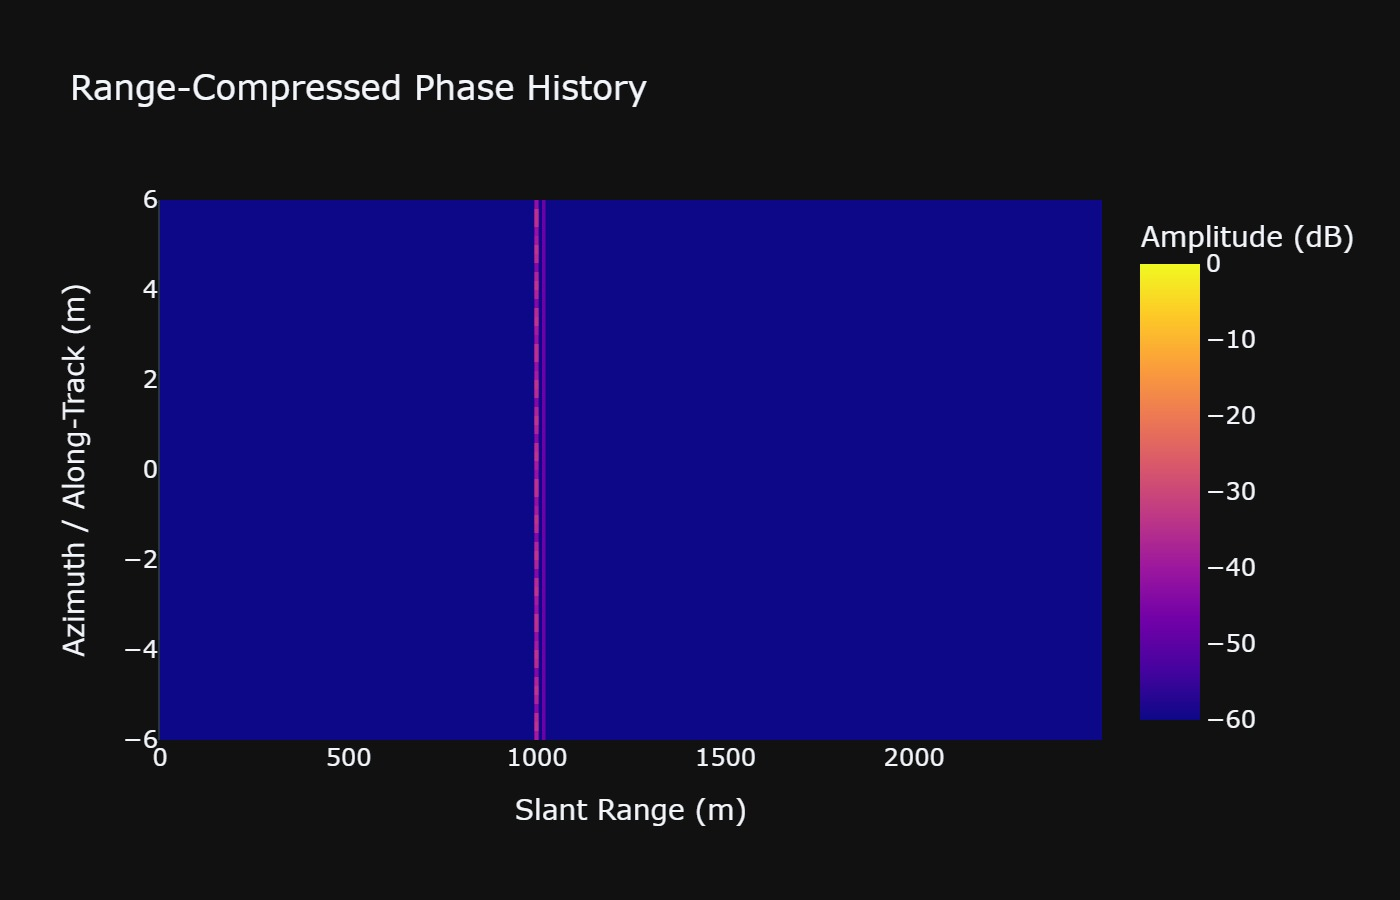

In [31]:
fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=slant_range, y=az_positions,
        z=20 * np.log10(np.abs(raw_mf[:, 0:1000]) + 1e-12),
        colorscale="Plasma",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-60, zmax=0,
    )
)
fig.update_layout(
    title="Range-Compressed Phase History",
    xaxis_title="Slant Range (m)",
    yaxis_title="Azimuth / Along-Track (m)",
    template="plotly_dark", height=450,
)
show(fig)

### Step 3: Back-Projection Focusing

Image grid sampled at half-resolution (2× oversampling) with a Hanning aperture window.

In [32]:
# ── Image grid ────────────────────────────────────────────────────────────────
range_window = 60          # ±60 m around r0
range_step   = range_res / 2   # 2× oversampled
img_ranges   = np.arange(r0 - range_window, r0 + range_window + range_step, range_step)

az_window  = 40            # ±40 m
az_step    = az_res_sar / 2    # 2× oversampled
img_az     = np.arange(-az_window, az_window + az_step, az_step)

print(f"Image grid: {len(img_az)} az × {len(img_ranges)} range pixels")
print(f"  Azimuth : {img_az[0]:.1f} to {img_az[-1]:.1f} m  (step {az_step:.2f} m)")
print(f"  Range   : {img_ranges[0]:.1f} to {img_ranges[-1]:.1f} m  (step {range_step:.2f} m)")

# ── Aperture tapering window ───────────────────────────────────────────────────
az_taper = np.hanning(num_pulses)   # −43 dB first sidelobe
# az_taper = np.hamming(num_pulses) # −43 dB, slightly wider main lobe
# az_taper = scipy.signal.windows.taylor(num_pulses, nbar=4, sll=35)  # −35 dB Taylor
# ── Back-projection ────────────────────────────────────────────────────────────
sar_image = np.zeros((len(img_az), len(img_ranges)), dtype=complex)
sample_coords = np.arange(samples_per_pulse)
for pulse_idx in range(num_pulses):
    x_n = platform_x[pulse_idx]
    w_n = az_taper[pulse_idx]          # ← aperture weight for this pulse
    dx  = img_az[np.newaxis, :] - x_n
    dy  = img_ranges[:, np.newaxis]
    R_n = np.sqrt(dx**2 + dy**2)
    sample_idx = 2.0 * R_n / c * fs
    valid = (sample_idx >= 0) & (sample_idx < samples_per_pulse - 1)
    si_flat = sample_idx.ravel()
    pulse_signal = raw_mf[pulse_idx]
    interp_re = np.interp(si_flat, sample_coords, pulse_signal.real, left=0.0, right=0.0)
    interp_im = np.interp(si_flat, sample_coords, pulse_signal.imag, left=0.0, right=0.0)
    interp_sig = (interp_re + 1j * interp_im).reshape(R_n.shape)
    interp_sig[~valid] = 0.0
    phase_corr = np.exp(-1j * 4.0 * np.pi * R_n / lam)
    sar_image += w_n * (interp_sig * phase_corr).T   # ← weighted accumulation

print("Back-projection complete.")
print(f"  SAR image shape : {sar_image.shape}  (Naz × Nr)")

Image grid: 321 az × 50 range pixels
  Azimuth : -40.0 to 40.0 m  (step 0.25 m)
  Range   : 940.0 to 1062.4 m  (step 2.50 m)
Back-projection complete.
  SAR image shape : (321, 50)  (Naz × Nr)


## Results: Focused SAR Image

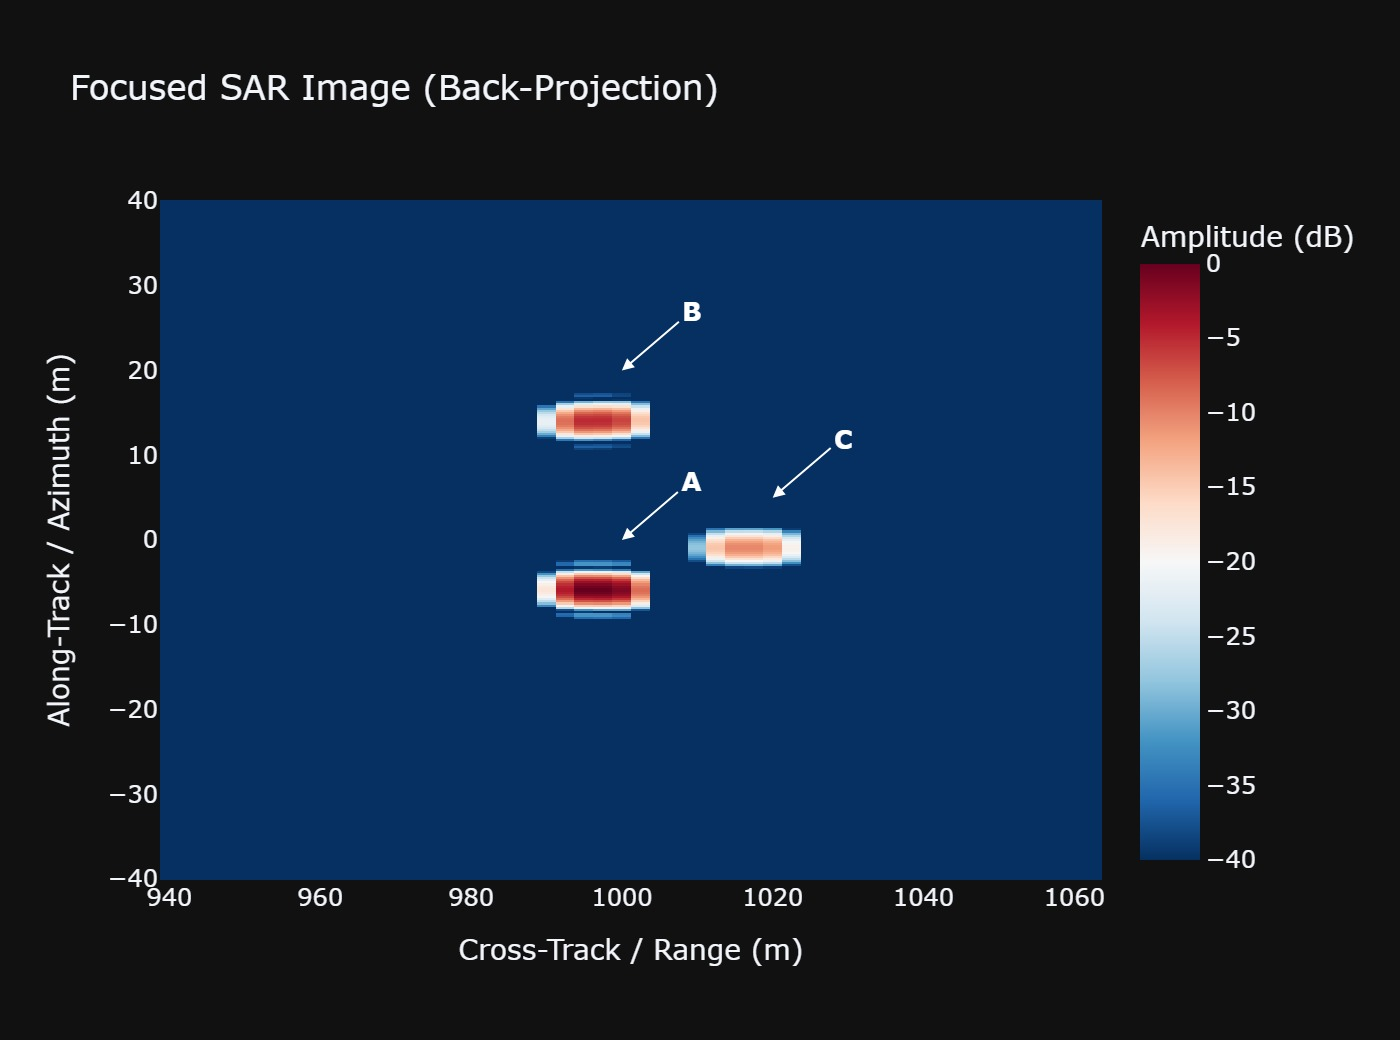

In [33]:
sar_amp_db = 20 * np.log10(np.abs(sar_image) + 1e-12)
sar_amp_db -= sar_amp_db.max()   # normalise to 0 dB

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=img_ranges, y=img_az,
        z=sar_amp_db,
        colorscale="RdBu_r",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-40, zmax=0,
    )
)

# Annotate ground-truth target positions
for tgt, lbl in zip(targets, ["A", "B", "C"]):
    x_t, y_t, _ = tgt["location"]
    fig.add_annotation(
        x=y_t, y=x_t, text=f"<b>{lbl}</b>",
        showarrow=True, arrowhead=2, arrowcolor="white",
        font=dict(color="white", size=13), arrowsize=1.2, ax=35, ay=-30,
    )

fig.update_layout(
    title="Focused SAR Image (Back-Projection)",
    xaxis_title="Cross-Track / Range (m)",
    yaxis_title="Along-Track / Azimuth (m)",
    template="plotly_dark", height=520,
)
show(fig)

### Range & Azimuth Profiles

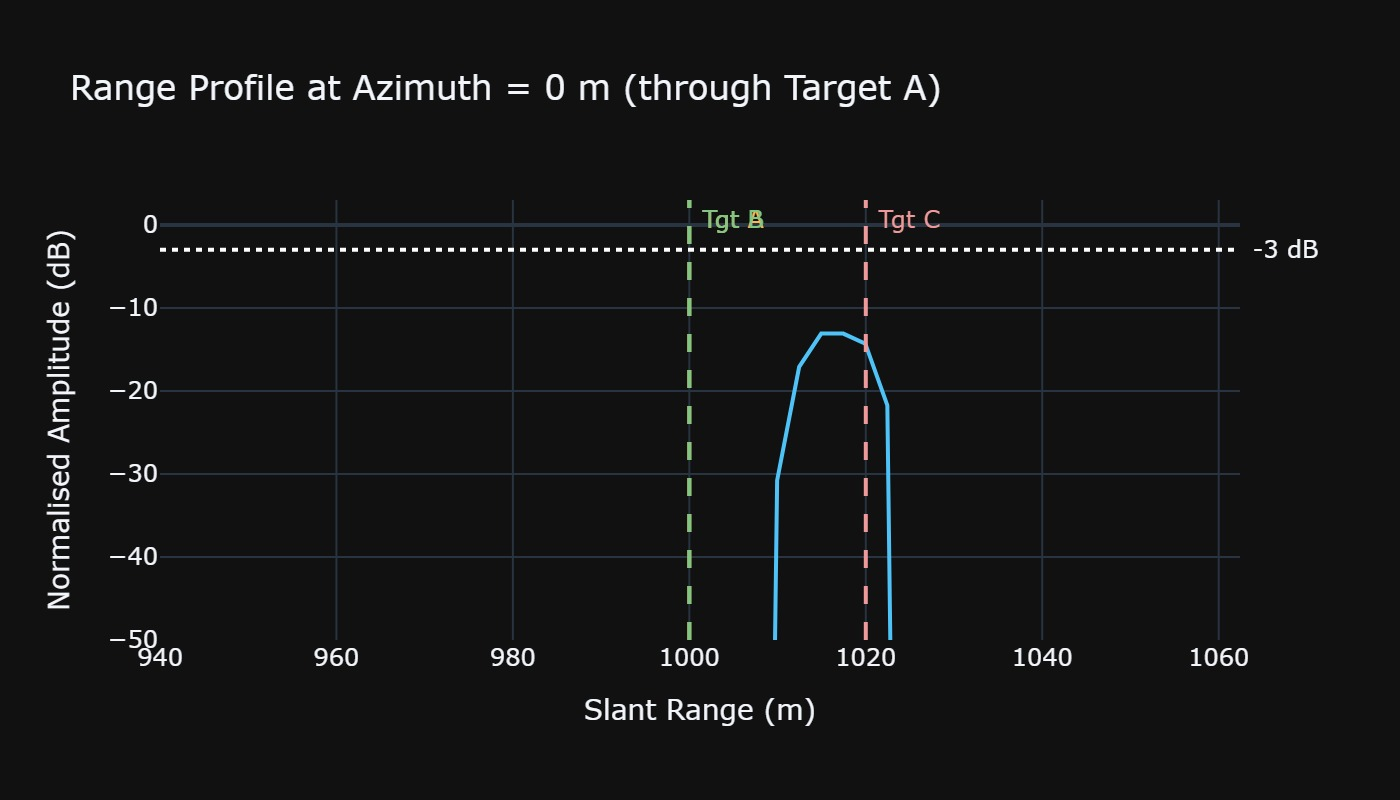

In [34]:
az_idx_A  = np.argmin(np.abs(img_az - 0.0))
range_slice = sar_amp_db[az_idx_A, :]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=img_ranges, y=range_slice,
        mode="lines", name="Range profile",
        line=dict(color="#4FC3F7", width=2),
    )
)
for tgt, lbl, col in zip(targets, ["A", "B", "C"],
                          ["#FFB74D", "#81C784", "#EF9A9A"]):
    x_t, y_t, _ = tgt["location"]
    fig.add_vline(x=y_t, line_dash="dash", line_color=col,
                  annotation_text=f" Tgt {lbl}",
                  annotation_position="top right",
                  annotation_font_color=col)

fig.add_hline(y=-3, line_dash="dot", line_color="white",
              annotation_text=" -3 dB", annotation_position="right")

fig.update_layout(
    title="Range Profile at Azimuth = 0 m (through Target A)",
    xaxis_title="Slant Range (m)",
    yaxis_title="Normalised Amplitude (dB)",
    yaxis=dict(range=[-50, 3]),
    template="plotly_dark", height=400,
)
show(fig)

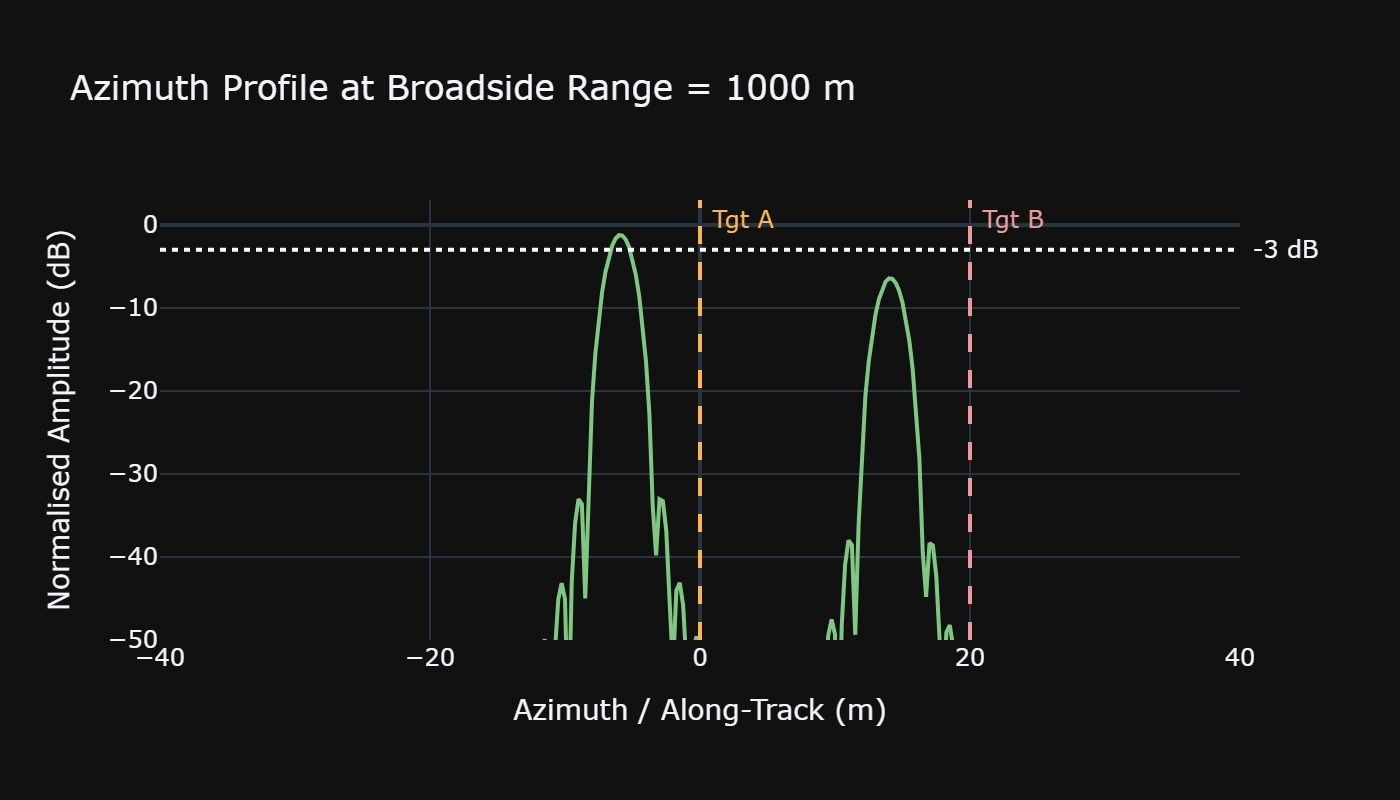

In [35]:
rng_idx_r0 = np.argmin(np.abs(img_ranges - r0))
az_slice = sar_amp_db[:, rng_idx_r0]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=img_az, y=az_slice,
        mode="lines", name="Azimuth profile",
        line=dict(color="#81C784", width=2),
    )
)
for tgt, lbl, col in zip(targets[:2], ["A", "B"],
                          ["#FFB74D", "#EF9A9A"]):
    x_t, y_t, _ = tgt["location"]
    fig.add_vline(x=x_t, line_dash="dash", line_color=col,
                  annotation_text=f" Tgt {lbl}",
                  annotation_position="top right",
                  annotation_font_color=col)

fig.add_hline(y=-3, line_dash="dot", line_color="white",
              annotation_text=" -3 dB", annotation_position="right")

fig.update_layout(
    title=f"Azimuth Profile at Broadside Range = {r0:.0f} m",
    xaxis_title="Azimuth / Along-Track (m)",
    yaxis_title="Normalised Amplitude (dB)",
    yaxis=dict(range=[-50, 3]),
    template="plotly_dark", height=400,
)
show(fig)

## Summary

Complete X-band strip-map SAR simulation with `RadarSimPy`:

| Step | Result |
|---|---|
| System design | $f_c$ = 10 GHz, B = 30 MHz, PRF = 500 Hz |
| Moving platform | v = 100 m/s, 60 pulses, aperture ≈ 11.9 m |
| Range compression | ΔR = 5 m (matched filter) |
| Back-projection | Δaz = 0.5 m, all 3 targets focused |